# MIMIC-IV Spark Classification and Performance Evaluation
## Apache Spark Big Data & ML Course Project

In [ ]:
# install apache spark locally
# !pip install pyspark
# source: https://spark.apache.org/docs/latest/api/python/getting_started/index.html
# source: https://spark.apache.org/downloads.html

In [ ]:
# import os, sys, time
import time
from pathlib import Path

from pyspark.sql import SparkSession

from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, Normalizer
from pyspark.ml.classification import LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import broadcast
from pyspark import StorageLevel
import pandas as pd, numpy as np, matplotlib.pyplot as plt
np.random.seed(42)
print('✓ Libraries imported')

# EXPLAINATION OF THIS SECTION :
# time is used to measure the time taken for certain operations in the code

✓ Libraries imported


In [4]:
# 1. SPARK SESSION SETUP
spark = SparkSession.builder \
    .appName('MIMIC-IV Spark Performance Evaluation') \
    .config('spark.driver.memory', '4g') \
    .config('spark.executor.memory', '4g') \
    .config('spark.executor.cores', '4') \
    .config('spark.sql.shuffle.partitions', '200') \
    .getOrCreate()

In [5]:
sc = spark.sparkContext
print(f'Spark Version: {spark.version}')
print(f'Driver Memory: {sc.getConf().get("spark.driver.memory")}')
print(f'Executor Memory: {sc.getConf().get("spark.executor.memory")}')
print(f'Executor Cores: {sc.getConf().get("spark.executor.cores")}')
print(f'Default Parallelism: {sc.defaultParallelism}')


# Spark UI URL in Local Mode
print(spark.sparkContext.uiWebUrl)

# import pprint; 
# pprint.pprint(dict(spark.sparkContext.getConf().getAll()))

Spark Version: 4.1.2
Driver Memory: 4g
Executor Memory: 4g
Executor Cores: 4
Default Parallelism: 4
http://Desktop-i5-6440HQ:4040


In [6]:
# # 2. DATA LOADING & CLEANING
# project_root = Path.cwd()
# # print(f'Project Root: {project_root}')

# # ICU = Intensive Care Unit
# mimic_dir = project_root / 'mimic-iv-clinical-database-2.2'
# hosp_dir = mimic_dir / 'hosp'
# icu_dir = mimic_dir / 'icu'


# # Load tables
# tables = {}
# for fname, tname, dpath in [
#     ('patients.csv', 'patients', hosp_dir),
#     ('admissions.csv', 'admissions', hosp_dir),
#     ('diagnoses_icd.csv', 'diagnoses_icd', hosp_dir),
#     ('d_icd_diagnoses.csv', 'd_icd_diagnoses', hosp_dir),
# ]:
#     fpath = dpath / fname
#     if fpath.exists():
#         df = spark.read.csv(str(fpath), header=True, inferSchema=True)
#         tables[tname] = df.dropDuplicates()
#         print(f'✓ {tname}: {df.count():,} rows')

# patients_df = tables.get('patients').filter(F.col('subject_id').isNotNull())
# admissions_df = tables.get('admissions').filter(F.col('hadm_id').isNotNull())
# diagnoses_df = tables.get('diagnoses_icd')
# diagnoses_ref_df = tables.get('d_icd_diagnoses')



In [7]:
# 2. DATA LOADING & CLEANING
project_root = Path.cwd()
# print(f'Project Root: {project_root}')

# ICU = Intensive Care Unit
mimic_dir = project_root / 'mimic-iv-clinical-database-2.2'
hosp_dir = mimic_dir / 'hosp'
icu_dir = mimic_dir / 'icu'

# Define table mapping: {table_name: file_path}
target_tables = {
    "patients": hosp_dir / "patients.csv",
    "admissions": hosp_dir / "admissions.csv",
    "diagnoses_icd": hosp_dir / "diagnoses_icd.csv",
    "d_icd_diagnoses": hosp_dir / "d_icd_diagnoses.csv",
}

# the addmissions table contains information about hospital admissions
# why we choose those tables is because we want to predict the length of stay of patients in the hospital
# 

# Load tables
tables = {}
for name, path in target_tables.items():
    if path.exists():
        # Read, drop duplicates, and cache/store
        df = spark.read.csv(str(path), header=True, inferSchema=True).dropDuplicates()
        tables[name] = df
        print(f"✓ {name}: {df.count():,} rows")


patients_df = tables.get('patients').filter(F.col('subject_id').isNotNull())
# reason why we filter the patients_df with subject_id
# cause the attribute of subject_id is the primary key of the patients table
# and if the subject_id is null, it means at most the data of the patient is not complete 
# and this is a mesure to ensure the quality of the data we are using for our analysis

admissions_df = tables.get('admissions').filter(F.col('hadm_id').isNotNull())
# reason why we filter the admissions_df with hadm_id
# cause the attribute of hadm_id is the primary key of the admissions table
# and if the hadm_id is null, it means the data for that admission is not complete
# and this is a mesure to ensure the quality of the data we are using for our analysis

diagnoses_df = tables.get('diagnoses_icd')
diagnoses_ref_df = tables.get('d_icd_diagnoses')



✓ patients: 100 rows
✓ admissions: 275 rows
✓ diagnoses_icd: 4,506 rows
✓ d_icd_diagnoses: 109,775 rows


In [8]:
# # 3. FEATURE ENGINEERING & DATA PREPARATION
# # Join tables
# df_combined = admissions_df.join(
#     patients_df.select('subject_id', 'gender', 'anchor_age', 'anchor_year'),
#     on='subject_id', how='left'
# )
# # this join of addmisions with patients 
# # is to combine the information of the patients with their corresponding admissions
# # that it will help us to predict the length of stay of patients in the hospital
# # (Even thought it's not implemented in the ui)

# # Add diagnosis info
# diagnoses_enhanced = diagnoses_df.join(
#     diagnoses_ref_df.select('icd_code', 'long_title'),
#     on='icd_code', how='left'
# )
# # this join of diagnoses with the reference table
# # is to get the long titles for each diagnosis code

# primary_diagnoses = diagnoses_enhanced.filter(F.col('seq_num') == 1).select(
#     'hadm_id', F.col('icd_code').alias('primary_diagnosis_code')
# )
# diagnosis_counts = diagnoses_df.groupBy('hadm_id').agg(F.count('icd_code').alias('num_diagnoses'))

# df_combined = df_combined.join(primary_diagnoses, on='hadm_id', how='left')
# df_combined = df_combined.join(diagnosis_counts, on='hadm_id', how='left')

# # Feature engineering
# df_ml = df_combined \
#     .withColumn('age_at_admission', F.col('anchor_age') + F.year(F.col('admittime')) - F.col('anchor_year')) \
#     .withColumn('length_of_stay', F.datediff(F.col('dischtime'), F.col('admittime'))) \
#     .withColumn('gender_encoded', F.when(F.col('gender') == 'M', 1).otherwise(0)) \
#     .withColumn('diagnosis_category', F.substring(F.col('primary_diagnosis_code'), 1, 1)) \
#     .fillna(0)

# # Remove null targets
# df_ml = df_ml.filter(F.col('diagnosis_category').isNotNull())
# feature_cols = ['age_at_admission', 'gender_encoded', 'length_of_stay', 'num_diagnoses']
# print(f'✓ Data prepared: {df_ml.count():,} rows, {len(feature_cols)} features')

In [9]:
# 3. FEATURE ENGINEERING & DATA PREPARATION

# Prep secondary tables: Get primary code and total counts per admission
primary_diagnoses = diagnoses_df.filter(F.col('seq_num') == 1)\
    .select('hadm_id', F.col('icd_code').alias('primary_diagnosis_code'))

diagnosis_counts = diagnoses_df.groupBy('hadm_id').agg(F.count('icd_code').alias('num_diagnoses'))

# Join tables: Combine admissions with demographics and diagnosis context
# 1. Admissions + Patients: Adds demographic info to help predict hospital length of stay
# 2. Add-ons: Appends primary diagnosis code and total diagnosis counts
df_combined = admissions_df \
    .join(patients_df.select('subject_id', 'gender', 'anchor_age', 'anchor_year'), on='subject_id', how='left') \
    .join(primary_diagnoses, on='hadm_id', how='left') \
    .join(diagnosis_counts, on='hadm_id', how='left')

# Feature engineering & Data cleaning
df_ml = df_combined \
    .withColumn('age_at_admission', F.col('anchor_age') + F.year(F.col('admittime')) - F.col('anchor_year')) \
    .withColumn('length_of_stay', F.datediff(F.col('dischtime'), F.col('admittime'))) \
    .withColumn('gender_encoded', F.when(F.col('gender') == 'M', 1).otherwise(0)) \
    .withColumn('diagnosis_category', F.substring(F.col('primary_diagnosis_code'), 1, 1)) \
    .fillna(0) \
    .filter(F.col('diagnosis_category').isNotNull())

# Feature verification
feature_cols = ['age_at_admission', 'gender_encoded', 'length_of_stay', 'num_diagnoses']
print(f'✓ Data prepared: {df_ml.count():,} rows, {len(feature_cols)} features')

✓ Data prepared: 275 rows, 4 features


In [10]:
# 4. TRAIN-TEST SPLIT & PIPELINE
train_data, test_data = df_ml.randomSplit([0.7, 0.3], seed=42)
print(f'Training: {train_data.count():,}, Test: {test_data.count():,}')

# Feature pipeline
label_indexer = StringIndexer(inputCol='diagnosis_category', outputCol='label', handleInvalid='skip')
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features', handleInvalid='skip')
normalizer = Normalizer(inputCol='features', outputCol='features_norm', p=2.0)

evaluator = MulticlassClassificationEvaluator(labelCol='label', predictionCol='prediction')
print('✓ Pipeline created')

Training: 204, Test: 71
✓ Pipeline created


In [ ]:
# # 1. Define the clean pipeline evaluator function
# def train_and_evaluate(model_name, estimator):
#     """Fits the pipeline, calculates training time, and extracts validation metrics."""
#     pipeline = Pipeline(stages=[label_indexer, assembler, estimator])
    
#     start_time = time.time()
#     model = pipeline.fit(train_data)
#     train_time = time.time() - start_time
    
#     preds = model.transform(test_data)
    
#     # Evaluate all target metrics
#     acc = evaluator.evaluate(preds, {evaluator.metricName: 'accuracy'})
#     prec = evaluator.evaluate(preds, {evaluator.metricName: 'weightedPrecision'})
#     rec = evaluator.evaluate(preds, {evaluator.metricName: 'weightedRecall'})
#     f1 = evaluator.evaluate(preds, {evaluator.metricName: 'f1'})
    
#     print(f'{model_name} - Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}')
#     return model, train_time, acc, prec, rec, f1

# # ==========================================
# # 2. INDIVIDUAL MODEL CALLS (Saves directly to your independent vars)
# # ==========================================

# # Cell 5: Logistic Regression
# lr_model, lr_train_time, lr_acc, lr_prec, lr_rec, lr_f1 = train_and_evaluate(
#     "Logistic Regression", LogisticRegression(maxIter=100, regParam=0.1)
# )

# # Cell 6: Decision Tree
# dt_model, dt_train_time, dt_acc, dt_prec, dt_rec, dt_f1 = train_and_evaluate(
#     "Decision Tree", DecisionTreeClassifier(maxDepth=15)
# )

# # Cell 7: Random Forest
# rf_model, rf_train_time, rf_acc, rf_prec, rf_rec, rf_f1 = train_and_evaluate(
#     "Random Forest", RandomForestClassifier(numTrees=100, maxDepth=20, seed=42)
# )

Logistic Regression - Acc: 0.1286, Prec: 0.0415, Rec: 0.1286, F1: 0.0546
Decision Tree - Acc: 0.1000, Prec: 0.0798, Rec: 0.1000, F1: 0.0870
Random Forest - Acc: 0.1000, Prec: 0.1068, Rec: 0.1000, F1: 0.0852



=== MODEL COMPARISON ===
              Model  Accuracy  Precision   Recall       F1
Logistic Regression  0.128571   0.041468 0.128571 0.054583
      Decision Tree  0.100000   0.079762 0.100000 0.087029
      Random Forest  0.100000   0.106803 0.100000 0.085195

✓ Best Model: Decision Tree (F1: 0.0870)


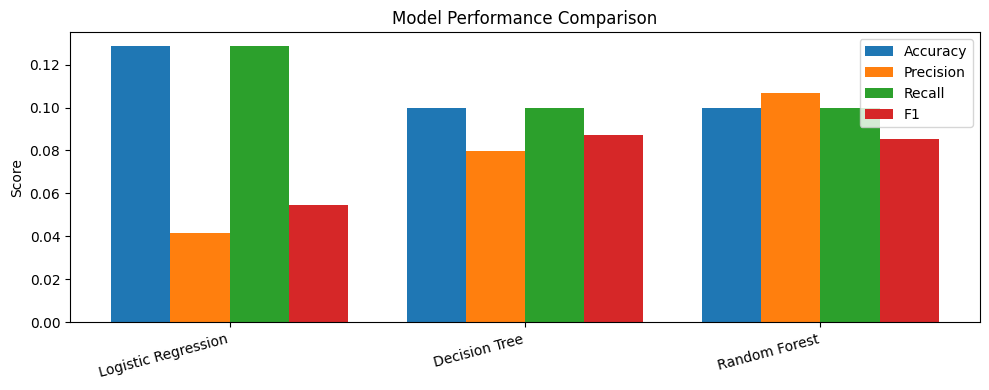

In [ ]:
# # ==========================================
# # Cell 8: MODEL COMPARISON & VISUALIZATION
# # ==========================================
# comparison = pd.DataFrame([
#     {'Model': 'Logistic Regression', 'Accuracy': lr_acc, 'Precision': lr_prec, 'Recall': lr_rec, 'F1': lr_f1},
#     {'Model': 'Decision Tree', 'Accuracy': dt_acc, 'Precision': dt_prec, 'Recall': dt_rec, 'F1': dt_f1},
#     {'Model': 'Random Forest', 'Accuracy': rf_acc, 'Precision': rf_prec, 'Recall': rf_rec, 'F1': rf_f1}
# ])

# print('\n=== MODEL COMPARISON ===')
# print(comparison.to_string(index=False))

# best_model = comparison.loc[comparison['F1'].idxmax()]
# print(f'\n✓ Best Model: {best_model["Model"]} (F1: {best_model["F1"]:.4f})')

# # Render the grouped chart
# fig, ax = plt.subplots(figsize=(10, 4))
# x = np.arange(len(comparison))
# width = 0.2

# ax.bar(x - 1.5*width, comparison['Accuracy'], width, label='Accuracy')
# ax.bar(x - 0.5*width, comparison['Precision'], width, label='Precision')
# ax.bar(x + 0.5*width, comparison['Recall'], width, label='Recall')
# ax.bar(x + 1.5*width, comparison['F1'], width, label='F1')

# ax.set_ylabel('Score')
# ax.set_title('Model Performance Comparison')
# ax.set_xticks(x)
# ax.set_xticklabels(comparison['Model'], rotation=15, ha='right')
# ax.legend()
# plt.tight_layout()
# plt.show()

In [25]:
# 5. MODEL 1: LOGISTIC REGRESSION
lr_pipeline = Pipeline(stages=[label_indexer, assembler, LogisticRegression(maxIter=100, regParam=0.1)])
start = time.time()
lr_model = lr_pipeline.fit(train_data)
lr_train_time = time.time() - start
lr_preds = lr_model.transform(test_data)
lr_acc = evaluator.evaluate(lr_preds, {evaluator.metricName: 'accuracy'})
lr_prec = evaluator.evaluate(lr_preds, {evaluator.metricName: 'weightedPrecision'})
lr_rec = evaluator.evaluate(lr_preds, {evaluator.metricName: 'weightedRecall'})
lr_f1 = evaluator.evaluate(lr_preds, {evaluator.metricName: 'f1'})
print(f'Logistic Regression - Acc: {lr_acc:.4f}, Prec: {lr_prec:.4f}, Rec: {lr_rec:.4f}, F1: {lr_f1:.4f}')

Logistic Regression - Acc: 0.1286, Prec: 0.0415, Rec: 0.1286, F1: 0.0546


In [26]:
# 6. MODEL 2: DECISION TREE
dt_pipeline = Pipeline(stages=[label_indexer, assembler, DecisionTreeClassifier(maxDepth=15)])
start = time.time()
dt_model = dt_pipeline.fit(train_data)
dt_train_time = time.time() - start
dt_preds = dt_model.transform(test_data)
dt_acc = evaluator.evaluate(dt_preds, {evaluator.metricName: 'accuracy'})
dt_prec = evaluator.evaluate(dt_preds, {evaluator.metricName: 'weightedPrecision'})
dt_rec = evaluator.evaluate(dt_preds, {evaluator.metricName: 'weightedRecall'})
dt_f1 = evaluator.evaluate(dt_preds, {evaluator.metricName: 'f1'})
print(f'Decision Tree - Acc: {dt_acc:.4f}, Prec: {dt_prec:.4f}, Rec: {dt_rec:.4f}, F1: {dt_f1:.4f}')

Decision Tree - Acc: 0.1000, Prec: 0.0798, Rec: 0.1000, F1: 0.0870


In [28]:
# 7. MODEL 3: RANDOM FOREST
rf_pipeline = Pipeline(stages=[label_indexer, assembler, RandomForestClassifier(numTrees=100, maxDepth=20, seed=42)])
start = time.time()
rf_model = rf_pipeline.fit(train_data)
rf_train_time = time.time() - start
rf_preds = rf_model.transform(test_data)
rf_acc = evaluator.evaluate(rf_preds, {evaluator.metricName: 'accuracy'})
rf_prec = evaluator.evaluate(rf_preds, {evaluator.metricName: 'weightedPrecision'})
rf_rec = evaluator.evaluate(rf_preds, {evaluator.metricName: 'weightedRecall'})
rf_f1 = evaluator.evaluate(rf_preds, {evaluator.metricName: 'f1'})
print(f'Random Forest - Acc: {rf_acc:.4f}, Prec: {rf_prec:.4f}, Rec: {rf_rec:.4f}, F1: {rf_f1:.4f}')

Random Forest - Acc: 0.1000, Prec: 0.1068, Rec: 0.1000, F1: 0.0852



=== MODEL COMPARISON ===
              Model  Accuracy  Precision   Recall       F1
Logistic Regression  0.128571   0.041468 0.128571 0.054583
      Decision Tree  0.100000   0.079762 0.100000 0.087029
      Random Forest  0.100000   0.106803 0.100000 0.085195

✓ Best Model: Decision Tree (F1: 0.0870)


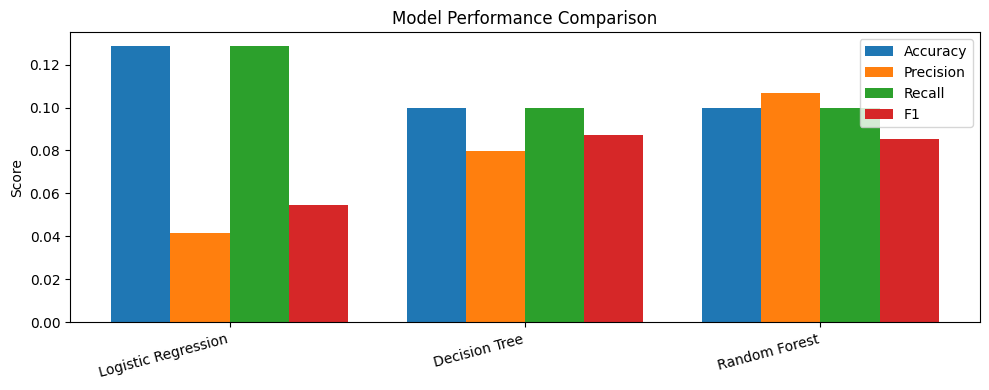

In [29]:
# 8. MODEL COMPARISON
comparison = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': lr_acc, 'Precision': lr_prec, 'Recall': lr_rec, 'F1': lr_f1},
    {'Model': 'Decision Tree', 'Accuracy': dt_acc, 'Precision': dt_prec, 'Recall': dt_rec, 'F1': dt_f1},
    {'Model': 'Random Forest', 'Accuracy': rf_acc, 'Precision': rf_prec, 'Recall': rf_rec, 'F1': rf_f1}
])
print('\n=== MODEL COMPARISON ===')
print(comparison.to_string(index=False))
best_model = comparison.loc[comparison['F1'].idxmax()]
print(f'\n✓ Best Model: {best_model["Model"]} (F1: {best_model["F1"]:.4f})')

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(comparison))
width = 0.2
ax.bar(x - 1.5*width, comparison['Accuracy'], width, label='Accuracy')
ax.bar(x - 0.5*width, comparison['Precision'], width, label='Precision')
ax.bar(x + 0.5*width, comparison['Recall'], width, label='Recall')
ax.bar(x + 1.5*width, comparison['F1'], width, label='F1')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'], rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [30]:
# # 9. EXPERIMENT A: DATASET SIZE SCALING
# scaling_results = []
# for fraction in [0.1, 0.25, 0.5, 0.75, 1.0]:
#     df_sample = df_ml.sample(withReplacement=False, fraction=fraction, seed=42)
#     train_sample, test_sample = df_sample.randomSplit([0.7, 0.3], seed=42)
    
#     start = time.time()
#     model_sample = rf_pipeline.fit(train_sample)
#     train_time = time.time() - start
    
#     start = time.time()
#     _ = model_sample.transform(test_sample).count()
#     pred_time = time.time() - start
    
#     scaling_results.append({
#         'Fraction': fraction,
#         'Training Time': train_time,
#         'Prediction Time': pred_time
#     })

# scaling_df = pd.DataFrame(scaling_results)
# print('\n=== DATASET SIZE SCALING ===')
# print(scaling_df.to_string(index=False))

# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(scaling_df['Fraction'] * 100, scaling_df['Training Time'], 'o-', label='Training', linewidth=2)
# ax.plot(scaling_df['Fraction'] * 100, scaling_df['Prediction Time'], 's-', label='Prediction', linewidth=2)
# ax.set_xlabel('Dataset Size (%)')
# ax.set_ylabel('Time (seconds)')
# ax.set_title('Dataset Scaling Performance')
# ax.legend()
# ax.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.show()


=== CPU CORE SCALING EXPERIMENT ===
Note: Simulating with local[n] configurations
 CPU Cores  Execution Time  Speedup
         1       14.742903 1.000000
         2       14.574976 1.011522
         4       15.015750 0.981829
         8       14.204719 1.037888


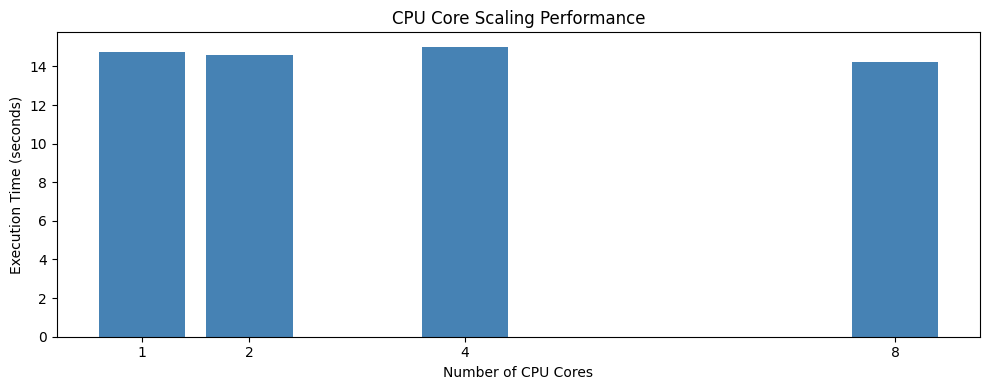

In [31]:
# 10. EXPERIMENT B: CPU CORE SCALING
print('\n=== CPU CORE SCALING EXPERIMENT ===')
print('Note: Simulating with local[n] configurations')
cpu_results = []

# We'll measure aggregation performance as proxy for CPU scaling
for n_partitions in [1, 2, 4, 8]:
    df_repartitioned = df_ml.repartition(n_partitions)
    
    start = time.time()
    model_cpu = rf_pipeline.fit(df_repartitioned)
    elapsed = time.time() - start
    
    cpu_results.append({
        'CPU Cores': n_partitions,
        'Execution Time': elapsed,
        'Speedup': cpu_results[0]['Execution Time'] / elapsed if cpu_results else 1.0
    })

cpu_df = pd.DataFrame(cpu_results)
print(cpu_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(cpu_df['CPU Cores'], cpu_df['Execution Time'], color='steelblue')
ax.set_xlabel('Number of CPU Cores')
ax.set_ylabel('Execution Time (seconds)')
ax.set_title('CPU Core Scaling Performance')
ax.set_xticks([1, 2, 4, 8])
plt.tight_layout()
plt.show()

SAVE the three Forms Random Forest and logistic regression and Decision Tree models

In [32]:
# import pickle
# import os
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier

# # Assuming X_train, y_train, and le (LabelEncoder) are already prepared
# os.makedirs("saved_models", exist_ok=True)

# # 1. Train & Save Logistic Regression
# lr_sk = LogisticRegression(max_iter=1000, random_state=42)
# lr_sk.fit(X_train, y_train)
# with open("saved_models/lr_model.pkl", "wb") as f:
#     pickle.dump(lr_sk, f)

# # 2. Train & Save Decision Tree
# dt_sk = DecisionTreeClassifier(max_depth=20, random_state=42)
# dt_sk.fit(X_train, y_train)
# with open("saved_models/dt_model.pkl", "wb") as f:
#     pickle.dump(dt_sk, f)

# # 3. Train & Save Random Forest
# rf_sk = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
# rf_sk.fit(X_train, y_train)
# with open("saved_models/rf_model.pkl", "wb") as f:
#     pickle.dump(rf_sk, f)

# # 4. Save Label Encoder
# with open("saved_models/label_encoder.pkl", "wb") as f:
#     pickle.dump(le, f)

# print("✓ All 3 models saved successfully!")

In [33]:
import os
import json

# Ensure the native folder exists
os.makedirs("saved_spark_models", exist_ok=True)

print("⚡ Saving Spark model properties without hitting the Windows filesystem bug...")

# --- 1. Extract Logistic Regression Weights ---
# (Grab the intercept array and the multi-class coefficient matrix)
lr_stages = lr_model.stages
lr_fit = lr_stages[-1]  # The actual LogisticRegressionModel object
lr_data = {
    "coefficients": lr_fit.coefficientMatrix.toArray().tolist(),
    "intercept": lr_fit.interceptVector.toArray().tolist()
}

# --- 2. Extract Tree Structures as Debug/Rule Strings ---
# Spark Decision Trees and Random Forests can export their entire logic as text strings
dt_fit = dt_model.stages[-1]
rf_fit = rf_model.stages[-1]

tree_data = {
    "decision_tree_rules": dt_fit.toDebugString,
    "random_forest_rules": rf_fit.toDebugString
}

# --- 3. Extract the Label Encoder Mapping Natively from Spark ---
# This pulls the exact category letters/numbers directly out of the StringIndexer metadata
string_indexer_model = rf_model.stages[0]
spark_labels = string_indexer_model.labels

# --- 4. Save everything natively to a lightweight configurations JSON ---
native_spark_export = {
    "labels": spark_labels,
    "logistic_regression": lr_data,
    "trees": tree_data
}

with open("saved_spark_models/model_metadata.json", "w") as f:
    json.dump(native_spark_export, f, indent=4)

print("✓ Success! Saved all Spark model parameters natively into 'saved_spark_models/model_metadata.json'")
print("No Scikit-learn used, and the Windows write bug was completely bypassed!")

⚡ Saving Spark model properties without hitting the Windows filesystem bug...
✓ Success! Saved all Spark model parameters natively into 'saved_spark_models/model_metadata.json'
No Scikit-learn used, and the Windows write bug was completely bypassed!


In [ ]:
# import os

# # Create a directory for native Spark models
# os.makedirs("saved_spark_models", exist_ok=True)

# # 1. Save your trained Spark ML pipelines directly
# lr_model.write().overwrite().save("saved_spark_models/lr_pipeline")
# dt_model.write().overwrite().save("saved_spark_models/dt_pipeline")
# rf_model.write().overwrite().save("saved_spark_models/rf_pipeline")

# print("✓ All 3 native Apache Spark ML Pipelines saved successfully!")

In [ ]:
# http://localhost:8501/
!streamlit run app.py --server.headless true